In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import os
from color_mapping import clean_color_column
from country_mapping import clean_country_column

file_path = os.path.expanduser("~/Desktop/regge.xlsx")
df = pd.read_excel(file_path)

official_apple_price = 949

model_discount = df[
    ["Preis", "Zustand", "Farbe", "Seller Rating", "Seller Type", "Herkunftsland"]
].copy()


def clean_price(x):
    if pd.isna(x):
        return np.nan
    x = (
        str(x)
        .replace("EUR", "")
        .replace("€", "")
        .replace(".", "")
        .replace(",", ".")
        .strip()
    )
    try:
        return float(x)
    except:
        return np.nan


def clean_rating(x):
    if pd.isna(x) or x == "N/A":
        return np.nan
    x = str(x).replace("%", "").replace(",", ".").strip()
    try:
        return float(x)
    except:
        return np.nan


model_discount["price"] = model_discount["Preis"].apply(clean_price)
model_discount["seller_rating"] = model_discount["Seller Rating"].apply(clean_rating)

model_discount["discount_eur"] = official_apple_price - model_discount["price"]
model_discount["discount_percent"] = (
    model_discount["discount_eur"] / official_apple_price
) * 100

model_discount["Zustand"] = (
    model_discount["Zustand"].astype(str).str.lower().str.strip()
)
model_discount["Farbe"] = model_discount["Farbe"].astype(str).str.lower().str.strip()

model_discount["Zustand"] = model_discount["Zustand"].replace(
    {"neu": "new", "gebraucht": "used", "refurbished": "refurbished"}
)

model_discount["Farbe"] = clean_color_column(model_discount["Farbe"])
model_discount["Herkunftsland"] = clean_country_column(model_discount["Herkunftsland"])


model_discount = model_discount.drop(columns=["Preis", "Seller Rating"])
model_discount = model_discount.dropna()

model_encoded = pd.get_dummies(
    model_discount,
    columns=["Zustand", "Farbe", "Seller Type", "Herkunftsland"],
    drop_first=True,
)

X = model_encoded.drop(["price", "discount_eur", "discount_percent"], axis=1)
y = model_encoded["discount_percent"]

X = X.astype(float)
y = y.astype(float)

X = sm.add_constant(X)

discount_model = sm.OLS(y, X).fit()

discount_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:       discount_percent   R-squared:                       0.238
Model:                            OLS   Adj. R-squared:                  0.201
Method:                 Least Squares   F-statistic:                     6.522
Date:                Sun, 03 May 2026   Prob (F-statistic):           4.50e-08
Time:                        19:00:36   Log-Likelihood:                -692.86
No. Observations:                 198   AIC:                             1406.
Df Residuals:                     188   BIC:                             1439.
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
=============================================================================================
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                        15.0736      2.715      5.551      0.000       9.717      20.430
seller_rating                -0.0433      0.014     -3.010      0.003      -0.072      -0.015
Zustand_refurbished           0.7461      2.018      0.370      0.712      -3.235       4.727
Zustand_used                  8.0604      1.914      4.210      0.000       4.284      11.837
Farbe_grün                   -1.5237      2.221     -0.686      0.494      -5.905       2.858
Farbe_lila                   -2.2256      2.114     -1.053      0.294      -6.395       1.944
Farbe_schwarz                -0.2988      1.719     -0.174      0.862      -3.690       3.092
Farbe_weiß                   -3.5944      1.979     -1.816      0.071      -7.498       0.309
Seller Type_Privat            2.5466      1.489      1.711      0.089      -0.390       5.483
Herkunftsland_deutschland    -0.1509      2.282     -0.066      0.947      -4.653       4.352
==============================================================================
Omnibus:                       17.782   Durbin-Watson:                   1.572
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               21.187
Skew:                          -0.647   Prob(JB):                     2.51e-05
Kurtosis:                       3.945   Cond. No.                         443.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [2]:
best_deals = model_discount.sort_values("discount_percent", ascending=False)

best_deals[
    [
        "price",
        "discount_eur",
        "discount_percent",
        "Zustand",
        "Farbe",
        "Seller Type",
        "Herkunftsland",
    ]
].head(15)

,price,discount_eur,discount_percent,Zustand,Farbe,Seller Type,Herkunftsland
169,679.00,270.00,28.451001,used,weiß,Privat,deutschland
171,680.00,269.00,28.345627,used,schwarz,Privat,deutschland
187,680.00,269.00,28.345627,new,blau,Privat,deutschland
89,699.90,249.10,26.248683,used,grün,Gewerblich,deutschland
81,699.90,249.10,26.248683,new,weiß,Gewerblich,deutschland
9,699.90,249.10,26.248683,used,blau,Gewerblich,deutschland
10,699.90,249.10,26.248683,used,schwarz,Gewerblich,deutschland
11,699.90,249.10,26.248683,used,weiß,Gewerblich,deutschland
156,699.99,249.01,26.239199,new,weiß,Privat,deutschland
192,699.99,249.01,26.239199,new,weiß,Privat,deutschland


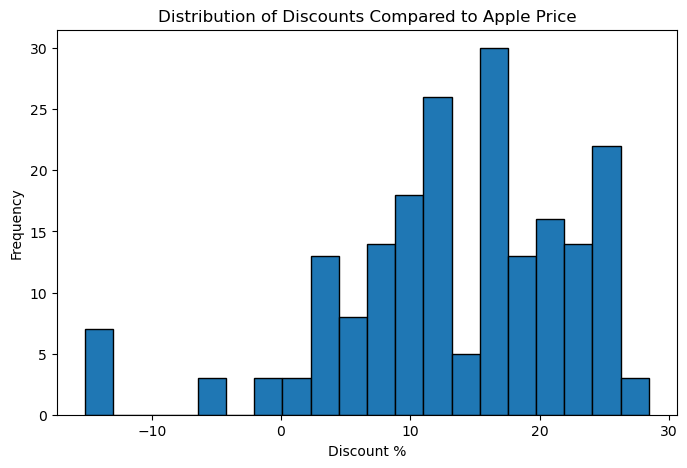

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(model_discount["discount_percent"], bins=20, edgecolor="black")
plt.xlabel("Discount %")
plt.ylabel("Frequency")
plt.title("Distribution of Discounts Compared to Apple Price")
plt.show()